In [1]:
import pandas as pd

df = pd.read_csv('../data/cleaned_data.csv')

In [2]:
#create customer segments based on purchase behavior
def segment(purchases):
    if purchases <= 2:
        return "Low Value"
    elif purchases <= 5:
        return "Medium Value"
    else:
        return "High Value"

df['customer_segment'] = df['total_purchases'].apply(segment)

In [3]:
#create segment distribution
df['customer_segment'].value_counts()

customer_segment
High Value      16597
Medium Value     1208
Low Value         178
Name: count, dtype: int64

In [4]:
#check segment distribution
df['customer_segment'].value_counts()

customer_segment
High Value      16597
Medium Value     1208
Low Value         178
Name: count, dtype: int64

In [5]:
#churn by segment
df.groupby('customer_segment')['churned'].mean()

customer_segment
High Value      0.246310
Low Value       0.808989
Medium Value    0.579470
Name: churned, dtype: float64

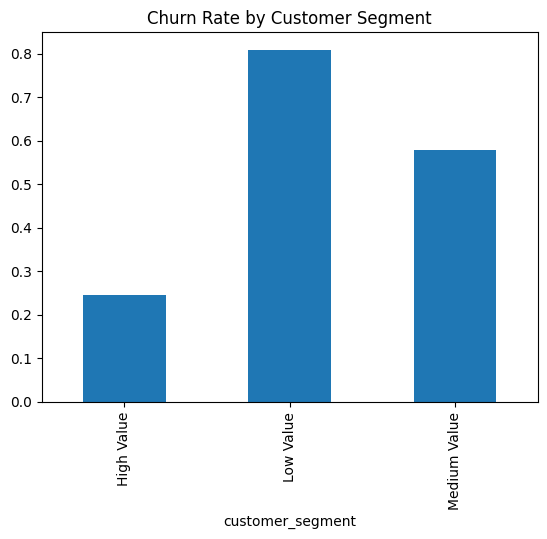

In [6]:
import matplotlib.pyplot as plt

df.groupby('customer_segment')['churned'].mean().plot(kind='bar')
plt.title("Churn Rate by Customer Segment")
plt.show()

In [7]:
#define risk
df['at_risk'] = ((df['cart_abandonment_rate'] > 0.7) & 
                 (df['login_frequency'] < 5)).astype(int)

In [8]:
#check risk vs churn
df.groupby('at_risk')['churned'].mean()

at_risk
0    0.234688
1    0.462400
Name: churned, dtype: float64

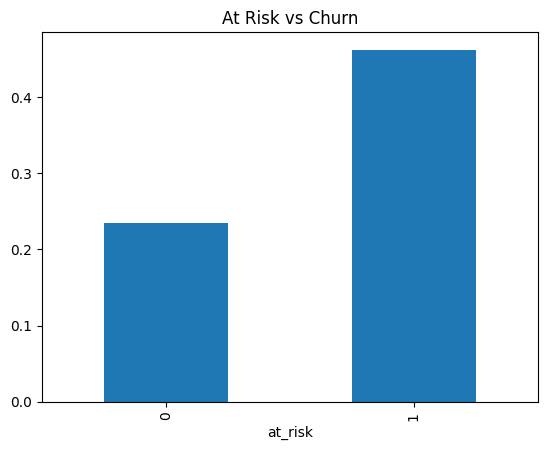

In [9]:
df.groupby('at_risk')['churned'].mean().plot(kind='bar')
plt.title("At Risk vs Churn")
plt.show()

Reduce cart abandonment via discounts/reminders
Improve engagement for low-frequency users
Target at-risk customers with personalized offers
Focus on converting medium-value users to high-value